## **Lexical Bridge Photo Mission - Data Collection**

### **Purpose**

The purpose of this notebook is to collect and prepare an image dataset for the Lexical Bridge photo mission feature. Images are downloaded from Open Images V7 using the FiftyOne dataset zoo, cropped using object bounding boxes, grouped into nine selected classes and three broader categories, then split into train, validation, and test sets. The final output is a zipped dataset file that can be reused for EDA and CNN model training.

### **Structure**
1. Install required libraries
2. Configure target classes, category mappings, and dataset paths
3. Download selected classes from Open Images V7
4. Extract bounding box crops from downloaded images
5. Clean temporary files
6. Split dataset into train, validation, and test sets
7. Visualize sample images
8. Export dataset as a ZIP file

## 1. Install Required Libraries

In [1]:
!pip install -q fiftyone pillow tqdm

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 3.5 MB/s eta 0:00

## 2. Dataset Configuration

In [2]:
import os
import random
import shutil
from pathlib import Path
from collections import defaultdict
from PIL import Image
from tqdm import tqdm

SEED = 42
random.seed(SEED)
# Require many samples for training own CNN model
TARGET_PER_CLASS = 1000
MAX_DOWNLOAD_SAMPLES = 25000
MIN_CROP_SIZE = 80  # Remove very small crops to improve training quality

# Map Open Images labels to the class names used in this project
FO_LABEL_MAP = {
    'Cat':       'cat',
    'Dog':       'dog',
    'Bird':      'bird',
    'Flower':    'flower',
    'Fruit':     'fruit',
    'Vegetable': 'vegetable',
    'Car':       'car',
    'Bicycle':   'bicycle',
    'Footwear':  'shoe',
}
FO_CLASSES = list(FO_LABEL_MAP.keys())

# Map detailed classes into broader game categories
CATEGORY_MAP = {
    'cat': 'animal',     'dog': 'animal',     'bird': 'animal',
    'flower': 'nature',  'fruit': 'nature',   'vegetable': 'nature',
    'car': 'daily_life', 'bicycle': 'daily_life', 'shoe': 'daily_life',
}

# Temporary working directories in the Colab environment
RAW_DIR     = Path('/content/open_images_raw')
CROP_DIR    = Path('/content/crops')
DATASET_DIR = Path('/content/dataset')

print(f'Classes: {list(CATEGORY_MAP.keys())}')
print(f'Target images per class: {TARGET_PER_CLASS}')
print(f'Maximum download samples: {MAX_DOWNLOAD_SAMPLES}')

Classes: ['cat', 'dog', 'bird', 'flower', 'fruit', 'vegetable', 'car', 'bicycle', 'shoe']
Target images per class: 1000
Maximum download samples: 25000


## 3. Download Open Images V7 Dataset

In [3]:
import fiftyone as fo
import fiftyone.zoo as foz

# Remove existing Open Images datasets to avoid conflicts
for ds_name in fo.list_datasets():
    if 'open-images' in ds_name:
        fo.delete_dataset(ds_name)
        print(f'Deleted: {ds_name}')
print(f'Downloading Open Images V7 for: {FO_CLASSES}')
print(f'Maximum download samples: {MAX_DOWNLOAD_SAMPLES}')

# Download selected classes from Open Images V7 using the FiftyOne dataset zoo
fo_dataset = foz.load_zoo_dataset(
    'open-images-v7',
    split='train',
    label_types=['detections'],
    classes=FO_CLASSES,
    max_samples=MAX_DOWNLOAD_SAMPLES,
    shuffle=True,
    seed=SEED,
    only_matching=True
)

print(f'\nDownloaded samples: {len(fo_dataset)}')

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Maximum download samples: 25000


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [9.0s elapsed, 0s remaining, 359.0Mb/s]      


...

 100% |█████████████| 25000/25000 [2.8m elapsed, 0s remaining, 180.2 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 25000/25000 [2.8m elapsed, 0s remaining, 180.2 samples/s]      


Dataset 'open-images-v7-train-25000' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-25000' created



Downloaded samples: 25000


## 4. Extract Bounding Box Crops

In [4]:
# Automatically detect the field that contains object detection labels
def get_detection_field(dataset):
    sample = dataset.first()
    for field_name in sample.field_names:
        value = sample.get_field(field_name)
        if isinstance(value, fo.core.labels.Detections):
            return field_name
    raise ValueError('No detection field found')

DETECTION_FIELD = get_detection_field(fo_dataset)
print(f'Detection field: {DETECTION_FIELD}')

# Reset the crop directory before saving new cropped images
if CROP_DIR.exists():
    shutil.rmtree(CROP_DIR)
for cls in FO_LABEL_MAP.values():
    (CROP_DIR / cls).mkdir(parents=True, exist_ok=True)

counts = defaultdict(int)
all_targets = set(FO_LABEL_MAP.values())

# Iterate through the downloaded images and extract object crops
for sample in tqdm(fo_dataset, desc='Cropping'):
    # Stop when all classes have reached the target number of images
    if all(counts[cls] >= TARGET_PER_CLASS for cls in all_targets):
        break
    try:
        image = Image.open(sample.filepath).convert('RGB')
    except:
        continue

    iw, ih = image.size
    detections = sample[DETECTION_FIELD].detections

    for det in detections:
        # Only keep labels selected for this project
        label = det.label
        if label not in FO_LABEL_MAP:
            continue
        cls = FO_LABEL_MAP[label]
        # Skip this class if the target count has already been reached
        if counts[cls] >= TARGET_PER_CLASS:
            continue

        # Convert normalized bounding box coordinates into pixel coordinates
        x, y, w, h = det.bounding_box
        left   = max(0,  int(x * iw))
        top    = max(0,  int(y * ih))
        right  = min(iw, int((x + w) * iw))
        bottom = min(ih, int((y + h) * ih))

        # Remove crops that are too small for reliable training
        if right - left < MIN_CROP_SIZE or bottom - top < MIN_CROP_SIZE:
            continue
        try:
            crop = image.crop((left, top, right, bottom))
            idx = counts[cls]
            crop.save(CROP_DIR / cls / f'{cls}_{idx:04d}.jpg', quality=95)
            counts[cls] += 1
        except:
            continue

print('\nCrop Summary')
for cls in sorted(all_targets):
    n = counts[cls]
    status = 'Complete' if n >= TARGET_PER_CLASS else 'Incomplete'
    print(f'  {status} {cls}: {n}/{TARGET_PER_CLASS}')
print(f'\nTotal cropped images: {sum(counts.values())}')

Detection field: ground_truth


Cropping: 100%|██████████| 25000/25000 [06:50<00:00, 60.85it/s]


Crop Summary
  Complete bicycle: 1000/1000
  Complete bird: 1000/1000
  Complete car: 1000/1000
  Complete cat: 1000/1000
  Complete dog: 1000/1000
  Complete flower: 1000/1000
  Complete fruit: 1000/1000
  Complete shoe: 1000/1000
  Incomplete vegetable: 885/1000

Total cropped images: 8885


## 5. Clean Temporary Files

In [5]:
# Remove raw images downloaded by FiftyOne to free up disk space
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
    print(f'Deleted: {RAW_DIR}')

# Remove the default FiftyOne cache directory
FO_CACHE = Path(os.path.expanduser('~/.fiftyone'))
if FO_CACHE.exists():
    shutil.rmtree(FO_CACHE)
    print(f'Deleted: {FO_CACHE}')

# Check remaining disk usage in the Colab environment
!df -h /content

Deleted: /root/.fiftyone
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   32G   76G  30% /


## 6. Split Dataset into Train, Validation, and Test Sets

In [6]:
# Reset the final dataset directory
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

# Create train, validation, and test folders for each class
for split in ['train', 'val', 'test']:
    for cls in CATEGORY_MAP:
        (DATASET_DIR / split / cls).mkdir(parents=True, exist_ok=True)

split_summary = {}

# Split cropped images into train / validation / test sets
for cls in CATEGORY_MAP:
    files = list((CROP_DIR / cls).glob('*.jpg'))
    random.shuffle(files)
    n = len(files)
    t1 = int(n * 0.70)
    t2 = int(n * 0.85)

    splits = {
        'train': files[:t1],
        'val':   files[t1:t2],
        'test':  files[t2:],
    }
    split_summary[cls] = {k: len(v) for k, v in splits.items()}

    # Copy each image into the corresponding split folder
    for split_name, file_list in splits.items():
        for f in file_list:
            shutil.copy(f, DATASET_DIR / split_name / cls / f.name)

print('Split Summary')
print(f'{"class":<12} {"train":>6} {"val":>6} {"test":>6} {"total":>6}')
print('-' * 41)
for cls, s in split_summary.items():
    total = s['train'] + s['val'] + s['test']
    print(f'{cls:<12} {s["train"]:>6} {s["val"]:>6} {s["test"]:>6} {total:>6}')

Split Summary
class         train    val   test  total
-----------------------------------------
cat             700    150    150   1000
dog             700    150    150   1000
bird            700    150    150   1000
flower          700    150    150   1000
fruit           700    150    150   1000
vegetable       619    133    133    885
car             700    150    150   1000
bicycle         700    150    150   1000
shoe            700    150    150   1000


## 7. Visualize Sample Images

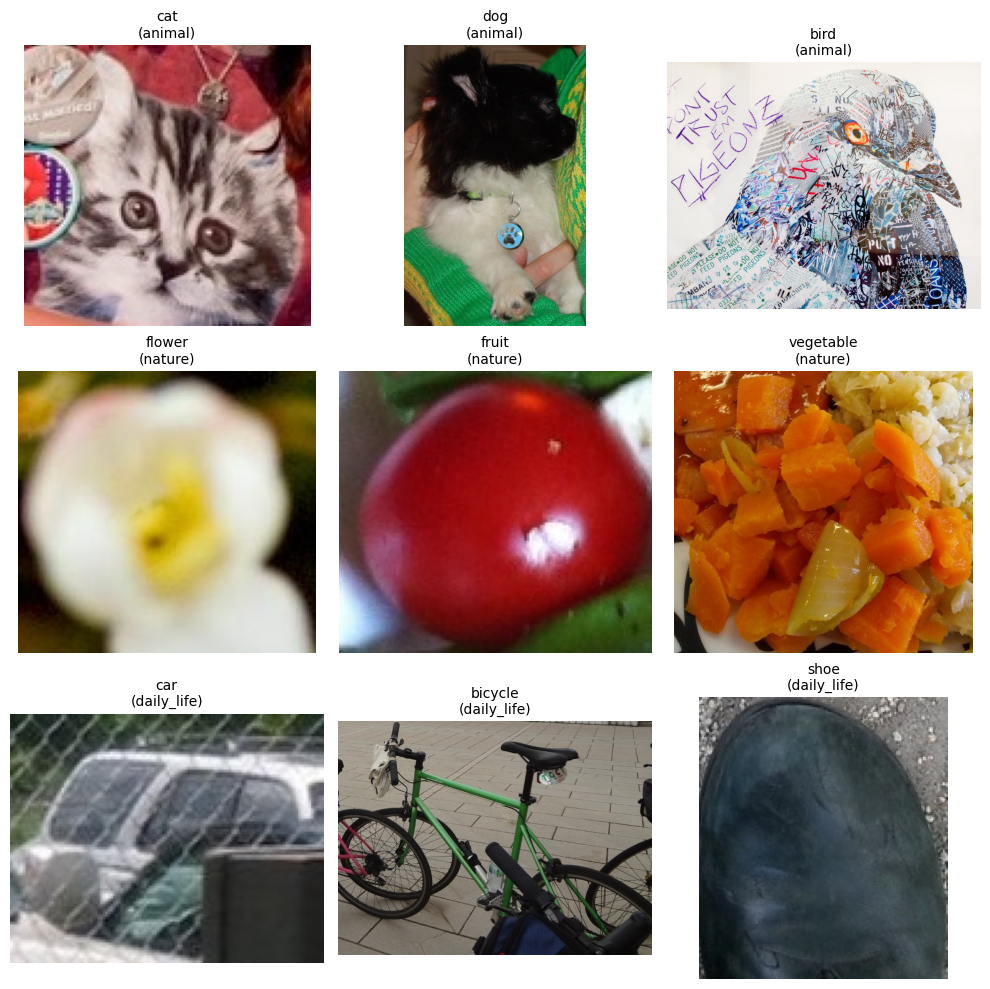

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
# Display one random training image from each class
for ax, cls in zip(axes.flatten(), CATEGORY_MAP.keys()):
    files = list((DATASET_DIR / 'train' / cls).glob('*.jpg'))
    if files:
        img = Image.open(random.choice(files)).convert('RGB')
        ax.imshow(img)

    # Show the class name and its broader category
    ax.set_title(f'{cls}\n({CATEGORY_MAP[cls]})', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Export Dataset as ZIP File and download

In [8]:
from google.colab import files
zip_path = '/content/dyslexiread_dataset'
shutil.make_archive(zip_path, 'zip', str(DATASET_DIR))

size_mb = Path(f'{zip_path}.zip').stat().st_size / (1024 * 1024)
print(f'ZIP file created: {zip_path}.zip ({size_mb:.1f} MB)')
files.download('/content/dyslexiread_dataset.zip')

ZIP file created: /content/dyslexiread_dataset.zip (519.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>